# Throw geometry statistics

Estimate the top-score neighborhood statistics from 4,000 random throws per initial sheet state.

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import polars as pl

logging.basicConfig(level=logging.ERROR, format='%(message)s')
logging.getLogger('matplotlib').setLevel(logging.WARNING)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'scratch' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import bot
import data_generation
import physics
import scoring
import state
from scratch.throw_geometry_statistics import (
    compute_nearest_throw_score_distribution,
    compute_throw_geometry_statistics,
)

In [2]:
NUM_STATES = 100
RANDOM_THROWS_PER_STATE = 500
TEAM = 1
SEED = 0

np.random.seed(SEED)
sheet_states = data_generation.random_sheet_states(
    team1=5, team2=4, num_sims=NUM_STATES
)
assert np.all(sheet_states.next_team_to_play() == TEAM)

throw_searcher = bot.RandomThrows(
    rng=np.random.default_rng(SEED),
    n_throws_to_generate=RANDOM_THROWS_PER_STATE,
)
throws, tiled_states = throw_searcher.get_throws_for_num_sims(
    team=TEAM, sheet_states=sheet_states
)
scores = scoring.get_net_score_for_team(
    physics.run_until_stopping(sheet_states=state.add_stones_from_throws(tiled_states, throws)),
    TEAM,
).reshape(RANDOM_THROWS_PER_STATE, NUM_STATES)

# Candidate-major/state-minor ordering means each state takes every NUM_STATES-th throw.
rows = []
score_distribution_matrices = []
all_score_values = np.unique(scores)
for sim_idx in range(NUM_STATES):
    state_throws = state.Throws(
        angle_deg=throws.angle_deg[sim_idx::NUM_STATES],
        speed=throws.speed[sim_idx::NUM_STATES],
        turn=throws.turn[sim_idx::NUM_STATES],
        y_val=throws.y_val[sim_idx::NUM_STATES],
        team=throws.team[sim_idx::NUM_STATES],
    )
    result = compute_throw_geometry_statistics(
        state_throws, scores[:, sim_idx],
    )
    score_distribution = compute_nearest_throw_score_distribution(
        state_throws, scores[:, sim_idx], score_values=all_score_values,
    )
    score_distribution_matrices.append(score_distribution.probabilities)
    valid = np.isfinite(result.distances)
    for row_idx, top_idx in enumerate(result.top_indices):
        lower_idx = result.nearest_lower_indices[row_idx]
        rows.append({
            'state': sim_idx,
            'top_score': result.top_score,
            'top_throw_index': int(top_idx),
            'top_turn': int(state_throws.turn[top_idx]),
            'top_angle_deg': state_throws.angle_deg[top_idx],
            'top_speed': state_throws.speed[top_idx],
            'top_y': state_throws.y_val[top_idx],
            'lower_throw_index': int(lower_idx),
            'distance_to_nearest_lower': result.distances[row_idx],
            'distance_percentile': result.distance_percentiles[row_idx],
        })

top_throw_statistics = pl.DataFrame(rows)
average_score_distribution = np.nanmean(score_distribution_matrices, axis=0)
top_throw_statistics

/home/vietafan/curling/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/vietafan/curling/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


state,top_score,top_throw_index,top_turn,top_angle_deg,top_speed,top_y,lower_throw_index,distance_to_nearest_lower,distance_percentile
i64,f64,i64,i64,f64,f64,f64,i64,f64,f64
0,2.0,19,0,-1.931378,2.320106,2.509521,275,0.129388,72.47191
0,2.0,243,-1,1.62526,2.311454,2.373211,109,0.137042,65.986395
0,2.0,254,-1,0.210047,2.382323,2.663546,209,0.087954,22.44898
0,2.0,288,-1,-0.022414,2.17811,2.537416,433,0.071027,13.605442
0,2.0,494,0,-2.135528,2.46893,2.606935,238,0.063515,15.730337
…,…,…,…,…,…,…,…,…,…
98,5.0,483,0,-0.861316,2.141966,2.308589,114,0.08587,32.075472
98,5.0,484,0,-0.623151,2.102691,2.553443,490,0.199956,98.742138
98,5.0,492,1,-1.446923,2.204841,2.482959,273,0.06298,15.819209


In [3]:
top_throw_statistics.select([
    pl.col('distance_to_nearest_lower').mean().alias('mean_distance'),
    pl.col('distance_to_nearest_lower').median().alias('median_distance'),
    pl.col('distance_percentile').mean().alias('mean_distance_percentile'),
    pl.col('distance_percentile').median().alias('median_distance_percentile'),
])

mean_distance,median_distance,mean_distance_percentile,median_distance_percentile
f64,f64,f64,f64
NaN,0.156823,NaN,66.575092


In [15]:
top_throw_statistics['distance_to_nearest_lower'].drop_nans().to_numpy().mean()

np.float64(0.15295555779160025)

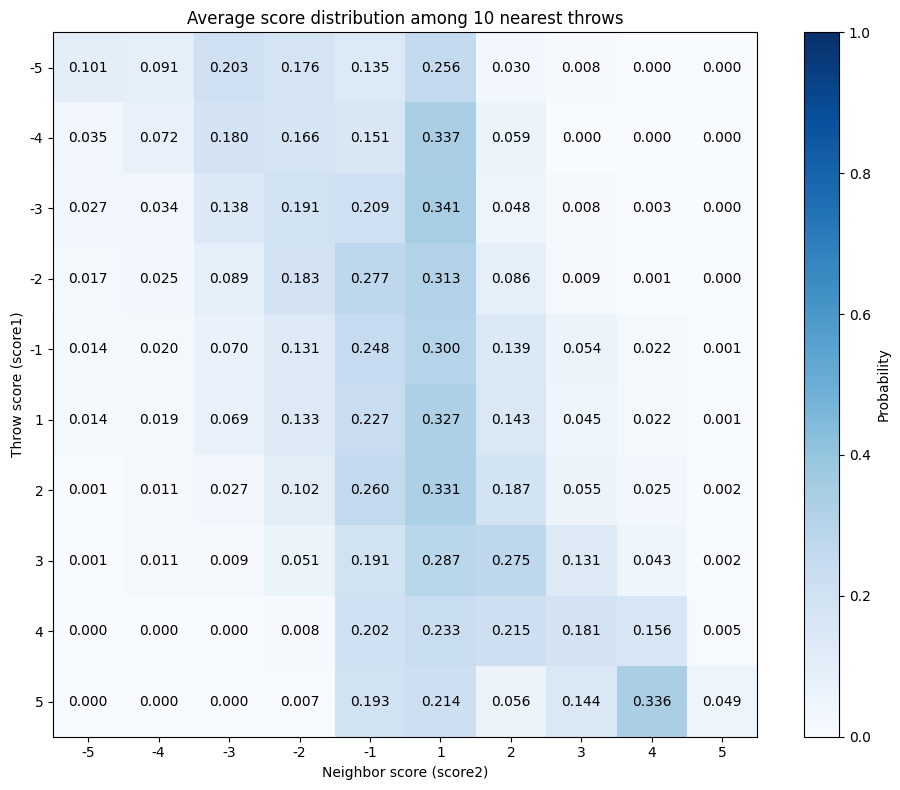

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))
image = ax.imshow(average_score_distribution, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(all_score_values)), labels=all_score_values)
ax.set_yticks(range(len(all_score_values)), labels=all_score_values)
ax.set_xlabel('Neighbor score (score2)')
ax.set_ylabel('Throw score (score1)')
ax.set_title('Average score distribution among 10 nearest throws')
for row in range(len(all_score_values)):
    for column in range(len(all_score_values)):
        ax.text(column, row, f'{average_score_distribution[row, column]:.3f}',
                ha='center', va='center')
fig.colorbar(image, ax=ax, label='Probability')
fig.tight_layout()
plt.show()
